In [1]:
# Data handling libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Hierarchical clustering model
from sklearn.cluster import AgglomerativeClustering

# Dendrogram tools
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv("spotify_tracks.csv")

df.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,-4.702460,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,-7.110031,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,-7.305120,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,-9.527256,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,-9.017653,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4


In [3]:
print("Dataset shape:", df.shape)

df.info()

Dataset shape: (50000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50000 non-null  object 
 1   track_name        50000 non-null  object 
 2   artist_name       50000 non-null  object 
 3   album_name        50000 non-null  object 
 4   release_year      50000 non-null  int64  
 5   genre             50000 non-null  object 
 6   popularity        50000 non-null  int64  
 7   duration_ms       50000 non-null  int64  
 8   explicit          50000 non-null  bool   
 9   danceability      50000 non-null  float64
 10  energy            50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  speechiness       50000 non-null  float64
 13  acousticness      50000 non-null  float64
 14  instrumentalness  50000 non-null  float64
 15  liveness          50000 non-null  float64
 16  valence      

In [4]:
df_sample = df.sample(n=1000, random_state=42)

print("Sampled dataset shape:", df_sample.shape)

Sampled dataset shape: (1000, 21)


In [5]:
# Convert True/False to 1/0

df_sample['explicit'] = df_sample['explicit'].astype(int)

In [6]:
# Convert genre categories into numeric labels

df_sample['genre_encoded'] = pd.factorize(df_sample['genre'])[0] + 1

df_sample[['genre','genre_encoded']].head()

,genre,genre_encoded
33553,r&b,1
9427,reggae,2
199,rock,3
12447,pop,4
39489,hip-hop,5


In [7]:
features = df_sample[['danceability','energy','loudness','speechiness',
                      'acousticness','instrumentalness','liveness',
                      'valence','tempo','popularity',
                      'explicit','genre_encoded']]

features.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity,explicit,genre_encoded
33553,0.757011,0.611749,-6.525607,0.047047,0.116921,0.084068,0.000000,0.521469,119.675530,22,0,1
9427,0.811173,0.415436,-8.307406,0.035748,0.319793,0.157493,0.193077,0.724951,82.733172,41,0,2
199,0.454217,0.750383,-0.892236,0.004457,0.074471,0.076565,0.268118,0.442964,101.228506,23,0,3
12447,0.912307,0.666866,-2.687160,0.056771,0.000000,0.000000,0.225879,0.521781,121.524915,25,0,4
39489,0.882240,0.587853,-7.394017,0.131809,0.209537,0.000000,0.167748,0.493734,82.321248,17,0,5


In [8]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features = pd.DataFrame(scaled_features, columns=features.columns)

scaled_features.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity,explicit,genre_encoded
0,0.631967,-0.215569,0.218103,-0.442572,-0.615712,-0.328268,-1.903487,-0.326595,0.087960,-0.061007,-0.377964,-1.359142
1,0.890187,-1.127919,-0.185223,-0.622065,0.151143,-0.027195,0.110905,0.812590,-1.465627,1.019258,-0.377964,-1.172473
2,-0.811603,0.428722,1.493265,-1.119109,-0.776170,-0.359035,0.893816,-0.766105,-0.687818,-0.004150,-0.377964,-0.985803
3,1.372344,0.040585,1.086969,-0.288114,-1.057672,-0.672988,0.453132,-0.324852,0.165735,0.109562,-0.377964,-0.799133
4,1.228999,-0.326622,0.021531,0.903851,-0.265624,-0.672988,-0.153356,-0.481871,-1.482951,-0.345287,-0.377964,-0.612463


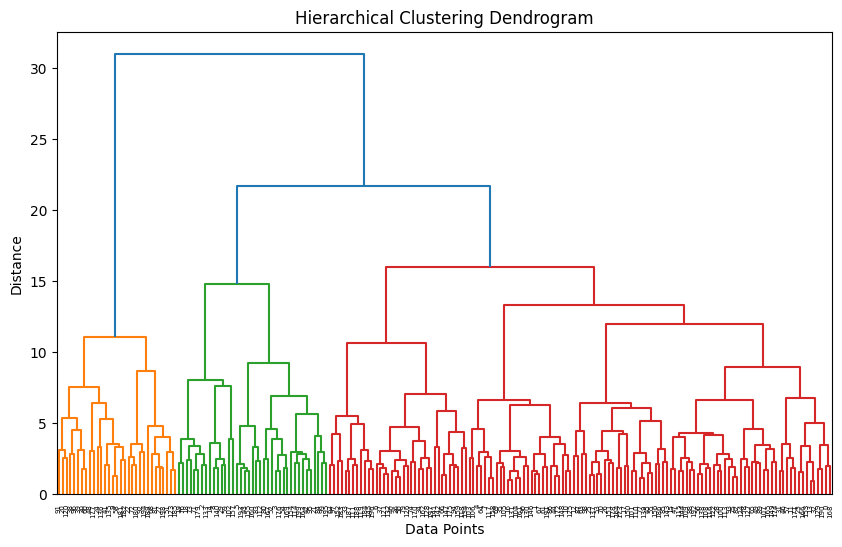

In [9]:
subset = scaled_features.sample(n=200, random_state=42)

linked = linkage(subset, method='ward')

plt.figure(figsize=(10,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Data Points")

plt.ylabel("Distance")

plt.show()

In [10]:
# Create hierarchical clustering model

hc = AgglomerativeClustering(n_clusters=4)

# Fit model and predict cluster labels

df_sample['Hierarchical_cluster'] = hc.fit_predict(scaled_features)

df_sample.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature,genre_encoded,Hierarchical_cluster
33553,wrOlAjN4PxGnwBd8q9twa1,Golden Heart (Remix),Neon Pulse,Forever Dance,2014,r&b,22,248364,0,0.757011,...,0.116921,0.084068,0.000000,0.521469,119.675530,0,0,4,1,0
9427,GLhxHcPwdhbmYQPee4X4Up,Slow Road (Live),Sam White,Sam's Greatest Hits,2006,reggae,41,230757,0,0.811173,...,0.319793,0.157493,0.193077,0.724951,82.733172,6,1,4,2,0
199,5gubCRDMqOucMC694Xi1Xr,My Fire,Lunar Echo,Volume 1,2011,rock,23,203245,0,0.454217,...,0.074471,0.076565,0.268118,0.442964,101.228506,9,1,4,3,0
12447,5Nc4zQgbBIBQwn4y6i7Asi,Falling Rain (feat. someone),The Drifters,The Light Album,2020,pop,25,175927,0,0.912307,...,0.000000,0.000000,0.225879,0.521781,121.524915,5,1,4,4,0
39489,RvHBcUreJ0NRaYPArkXQBN,Rising Love (Acoustic Version),Desert Wind,Volume 3,2011,hip-hop,17,173214,0,0.882240,...,0.209537,0.000000,0.167748,0.493734,82.321248,10,0,4,5,0


In [11]:
df_sample['Hierarchical_cluster'].value_counts()

,count
Hierarchical_cluster,
0,516
2,299
1,109
3,76


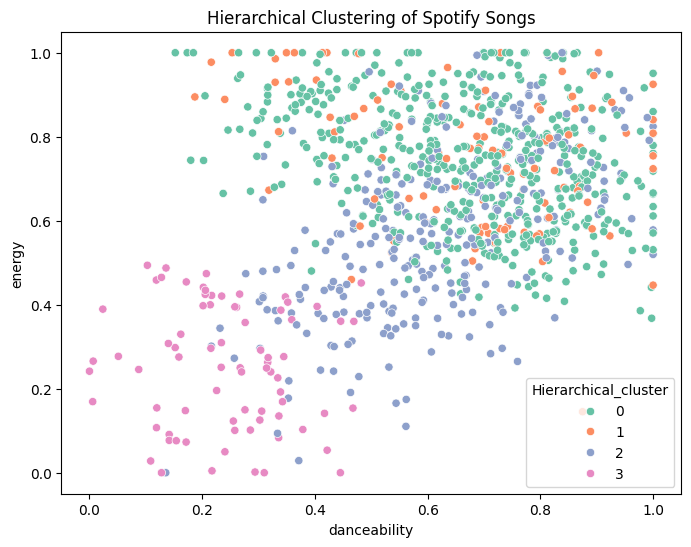

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_sample['danceability'],
    y=df_sample['energy'],
    hue=df_sample['Hierarchical_cluster'],
    palette='Set2'
)

plt.title("Hierarchical Clustering of Spotify Songs")

plt.show()

In [13]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_features, df_sample['Hierarchical_cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.16038360637356577
